# Test plots notebook
This notebook helps exercise the plotting wrappers in `synco.plotting.distributions` and `synco.plotting.performance`.

Usage:
- Edit the `results_dir` and `plots_dir` cells below to point to a dataset in the repository.
- Run the cells step-by-step to see which files are produced and if any dependencies or column-name mismatches appear.

In [1]:
# Setup: imports and non-interactive backend
import sys
import platform
import importlib
import pathlib
from pathlib import Path

import matplotlib
matplotlib.use('Agg')  # headless backend for CI / notebooks without display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly

# Display package versions
print('Python:', sys.version.splitlines()[0])
print('Platform:', platform.platform())
print('Pandas:', pd.__version__)
print('NumPy:', np.__version__)
print('Matplotlib:', matplotlib.__version__)
print('Plotly:', plotly.__version__)

# Check kaleido availability
try:
    import kaleido
    # Some kaleido distributions do not set a __version__ attribute;
    # try to read it, otherwise fall back to importlib.metadata.
    try:
        v = kaleido.__version__
    except Exception:
        try:
            from importlib import metadata
            v = metadata.version('kaleido')
        except Exception:
            v = 'unknown'
    print('Kaleido available:', v)
except Exception as e:
    print('Kaleido not available:', e)
    print("If you need to save Plotly images, install with: pip install kaleido")

Python: 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:05:38) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
Pandas: 2.3.3
NumPy: 2.3.5
Matplotlib: 3.10.7
Plotly: 6.5.0
Kaleido available: 1.2.0


In [2]:
# Parameters: set paths and options
from pathlib import Path

# Default example paths (edit these to point to your real results)
BASE = Path('oncologics')  # repo-relative base — change to your results directory
results_dir = Path(BASE) / '20251013' / 'synco_output'
plots_dir = Path(results_dir) / 'plots_test'
show = True  # whether to display interactive figures

print('results_dir =', results_dir)
print('plots_dir =', plots_dir)
plots_dir.mkdir(parents=True, exist_ok=True)

results_dir = oncologics\20251013\synco_output
plots_dir = oncologics\20251013\synco_output\plots_test


In [3]:
# Helper utilities: checksums and image display
import hashlib
from PIL import Image
import numpy as np
from IPython.display import display


def sha256_of_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, 'rb') as fh:
        for chunk in iter(lambda: fh.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()


def show_image(path: Path):
    try:
        img = Image.open(path)
        display(img)
    except Exception as e:
        print('Failed to open image', path, e)


def diff_images(path_a: Path, path_b: Path) -> dict:
    """Compute basic pixel-diff statistics between two images."""
    a = np.array(Image.open(path_a).convert('RGBA'))
    b = np.array(Image.open(path_b).convert('RGBA'))
    # Resize smaller to larger if shapes differ (simple fallback)
    if a.shape != b.shape:
        print('Image shapes differ:', a.shape, b.shape)
        return {'mse': float('inf'), 'mean_abs': float('inf')}
    diff = np.abs(a.astype(int) - b.astype(int))
    mse = np.mean(diff.astype(float) ** 2)
    mean_abs = np.mean(diff)
    return {'mse': float(mse), 'mean_abs': float(mean_abs)}


In [ ]:
# Import wrappers and run distribution plots
from synco.plotting.distributions import make_pred_distribution_plots

print('Calling distribution wrapper...')
make_pred_distribution_plots(str(results_dir), plots_dir=str(plots_dir), show=False)
print('Distribution plots finished.\n')


Calling distribution wrapper...


Wait expired, Browser is being closed by watchdog.


Distribution plots finished.



Wait expired, Browser is being closed by watchdog.


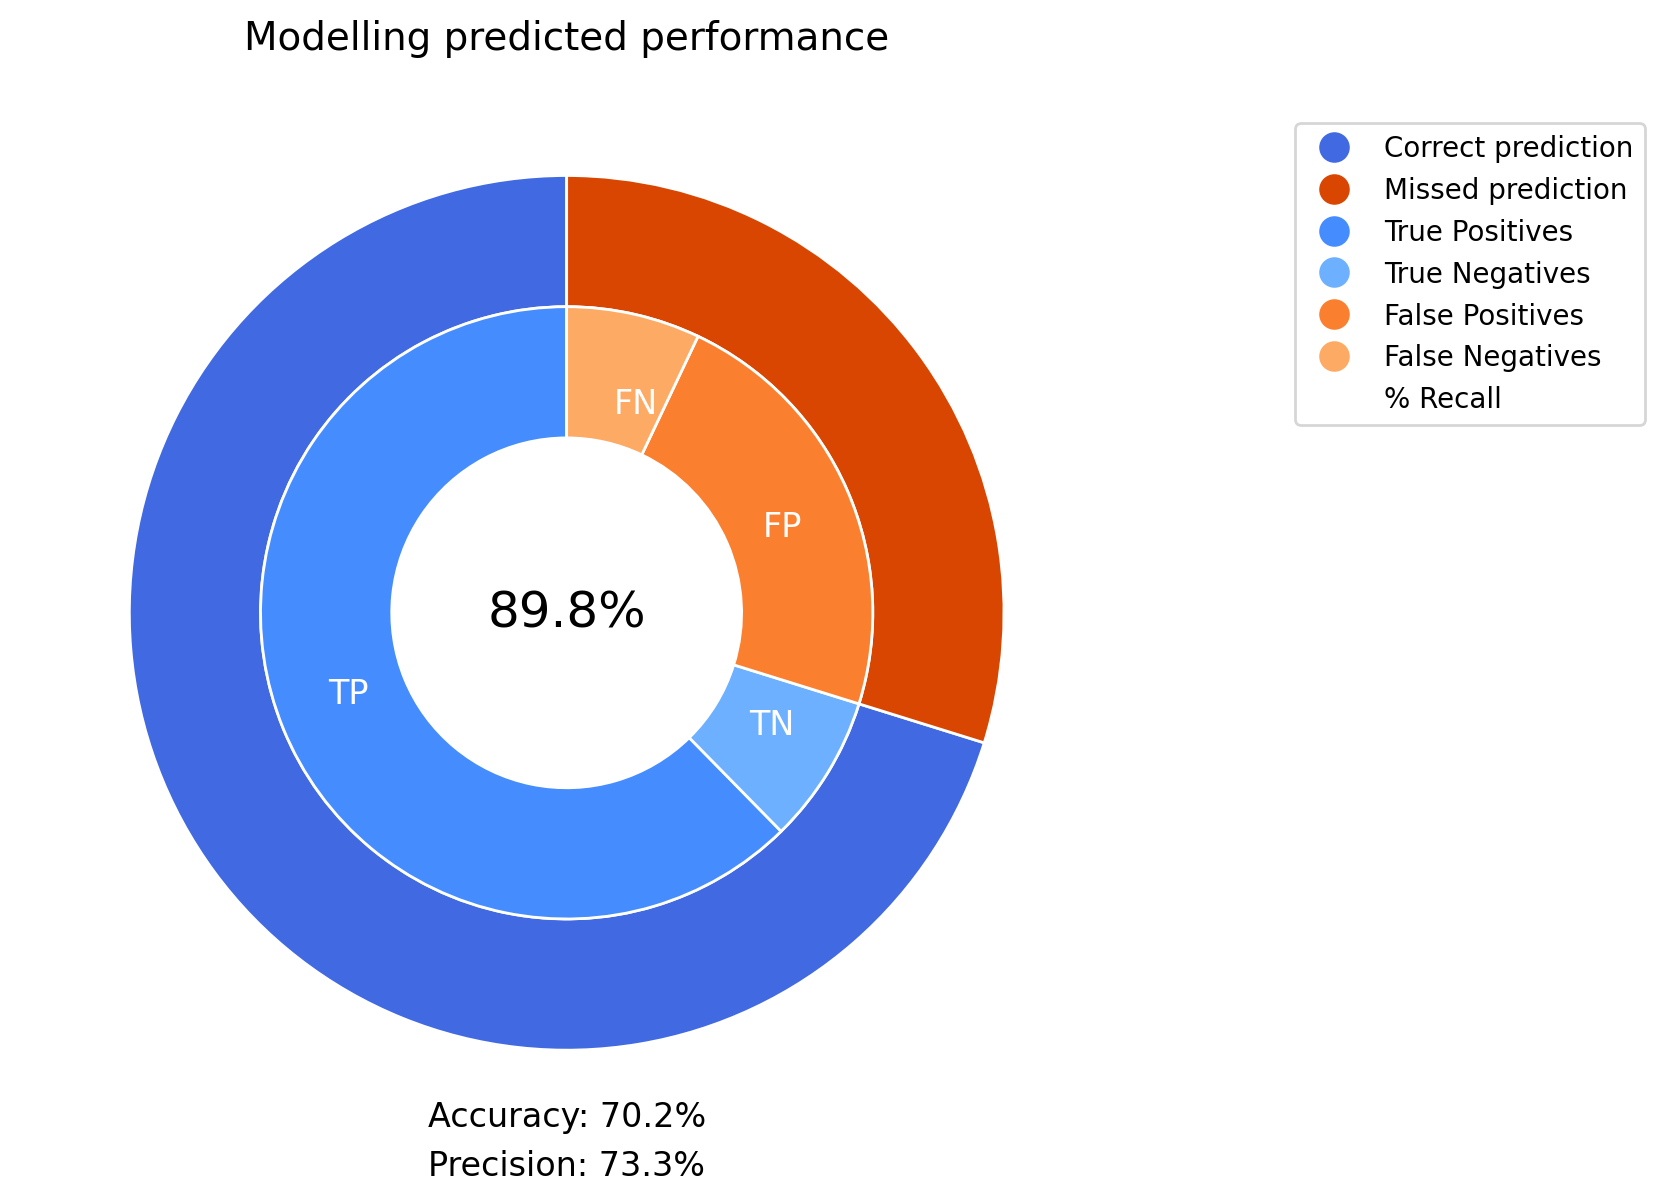

Performance plots finished.



In [ ]:
from synco.plotting.performance import make_performance_plots

make_performance_plots(str(results_dir), plots_dir=str(plots_dir), show=show)
print('Performance plots finished.\n')


In [4]:
from synco.plotting.performance import make_ring_plots

make_ring_plots(str(results_dir), plots_dir=str(plots_dir), show=show,
                analysis_type="inhibitor_combination"
                )

In [4]:
# Classification plots
from synco.plotting.classification import make_classification_plots
print('Calling classification wrapper...')
make_classification_plots(str(results_dir), plots_dir=str(plots_dir), show=show,
                          analysis_type="combination", debug=False
                          )
print('Classification plots finished.\n')

Calling classification wrapper...


Wait expired, Browser is being closed by watchdog.


Wait expired, Browser is being closed by watchdog.


Wait expired, Browser is being closed by watchdog.


Classification plots finished.

